# EN3160 Image Processing & Computer Vision - Assignment 01
**Name:** Meedeniya M.M.H

**Index Number:** 230407K

**GitHub Repository:** https://github.com/manjarimeedeniya/EN3160-Assignment-01

In [22]:
# Importing required libraries
import cv2 as cv
import numpy as np 
import matplotlib.pyplot as plt

## Question 1

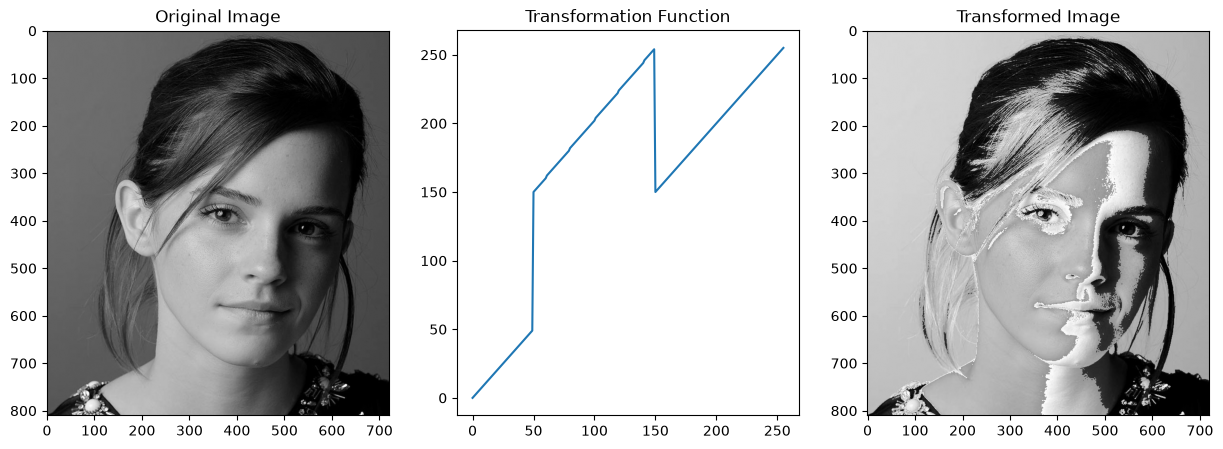

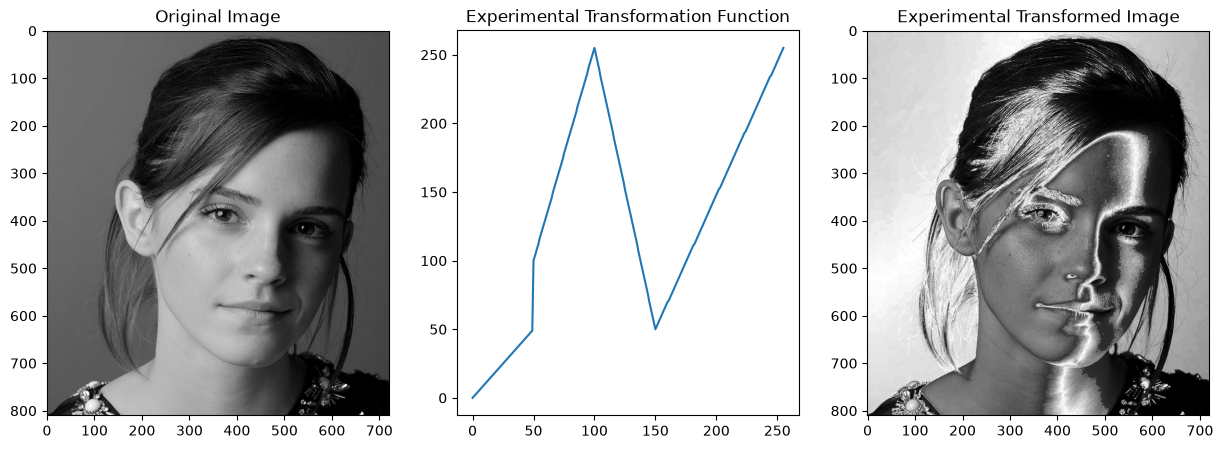

In [54]:
def intensity_transform(im,breakpoints):
    # Create an empty lookup table for intensities 0-255
    transform = np.zeros(256, dtype=np.uint8)

    # Generate each piecewise-linear segment
    for i in range(len(breakpoints) - 1):

        x1, y1 = breakpoints[i]
        x2, y2 = breakpoints[i + 1]
        if x2 == x1:
            continue

        # Input intensity values in this segment
        x = np.arange(x1, x2 + 1)

        # Linear interpolation
        y = y1 + (y2 - y1) * (x - x1) / (x2 - x1)

        transform[x] = np.round(y).astype(np.uint8)

    # Apply transformation using LUT
    transformed_image = cv.LUT(im, transform)

    return transformed_image, transform    



image1 = cv.imread('C:\\Users\\USER\\EN3160-Assignment-01\\images\\question1.jpeg',cv.IMREAD_GRAYSCALE)  # Read the first image in grayscale

bps = np.array([[0,0],[50,50],[50,150],[150,255],[150,150],[255,255]])  # Define breakpoints 
bps1 = np.array([[0,0],[50,50],[50,100],[100,255],[150,50],[255,255]])

image_transformed,transform=intensity_transform(image1, bps)
image_with_experimental_transform,transform1=intensity_transform(image1, bps1)

# Display the original and transformed images
fig,axes=plt.subplots(1,3,figsize=(15,5))
axes[0].imshow(image1,cmap='gray')
axes[0].set_title('Original Image')
axes[2].imshow(image_transformed,cmap='gray')
axes[2].set_title('Transformed Image') 
axes[1].plot(transform)
axes[1].set_title('Transformation Function')    
plt.show()  # Show the plots

fig,axes=plt.subplots(1,3,figsize=(15,5))
axes[0].imshow(image1,cmap='gray')
axes[0].set_title('Original Image')
axes[2].imshow(image_with_experimental_transform,cmap='gray')
axes[2].set_title('Experimental Transformed Image') 
axes[1].plot(transform1)
axes[1].set_title('Experimental Transformation Function')    
plt.show()  # Show the plots

## Question 2

Detected Peaks -> Gray Matter: 149, White Matter: 169


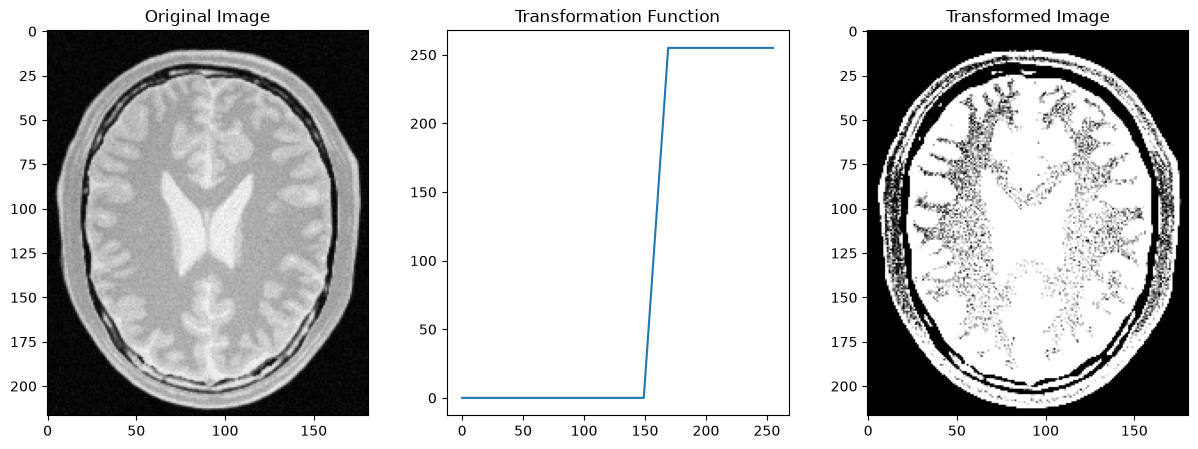

In [57]:
# 1. Load image
mri_image = cv.imread('C:\\Users\\USER\\EN3160-Assignment-01\\images\\question2.jpeg', cv.IMREAD_GRAYSCALE)

# 2. Calculate histogram (ignoring pure black background < 10)
hist = cv.calcHist([mri_image], [0], None, [256], [0, 256]).flatten()
hist[:10] = 0  # Ignore background zeros

# 3. Smooth histogram using a simple moving average to clear noise
kernel = np.ones(15) / 15
smoothed_hist = np.convolve(hist, kernel, mode='same')

# 4. Find tissue ranges by splitting histogram into mid and high intensity regions
# Gray matter peak is in the middle (e.g., 50 to 150)
gm_peak = np.argmax(smoothed_hist[50:150]) + 50

# White matter peak is in the higher region (e.g., 150 to 240)
wm_peak = np.argmax(smoothed_hist[150:240]) + 150

print(f"Detected Peaks -> Gray Matter: {gm_peak}, White Matter: {wm_peak}")

# 5. Build dynamic breakpoints automatically
# (a) White Matter Accentuation: Ramps up around white matter peak
bps_wm_auto = np.array([
    [0, 0],
    [gm_peak, 0],
    [wm_peak, 255],
    [255, 255]
])

# (b) Gray Matter Accentuation: Peak shape around gray matter intensity
bps_gm_auto = np.array([
    [0, 0],
    [gm_peak - 30, 0],
    [gm_peak, 255],
    [wm_peak, 0],
    [255, 0]
])

# Apply transformations using your existing function
img_wm, transform_wm = intensity_transform(mri_image, bps_wm_auto)
img_gm, transform_gm = intensity_transform(mri_image, bps_gm_auto)

# Display the original and transformed images
fig,axes=plt.subplots(1,3,figsize=(15,5))
axes[0].imshow(mri_image,cmap='gray')
axes[0].set_title('Original Image')
axes[2].imshow(img_wm,cmap='gray')
axes[2].set_title('Transformed Image') 
axes[1].plot(transform_wm)
axes[1].set_title('Transformation Function')    
plt.show()  # Show the plots

## Question 3

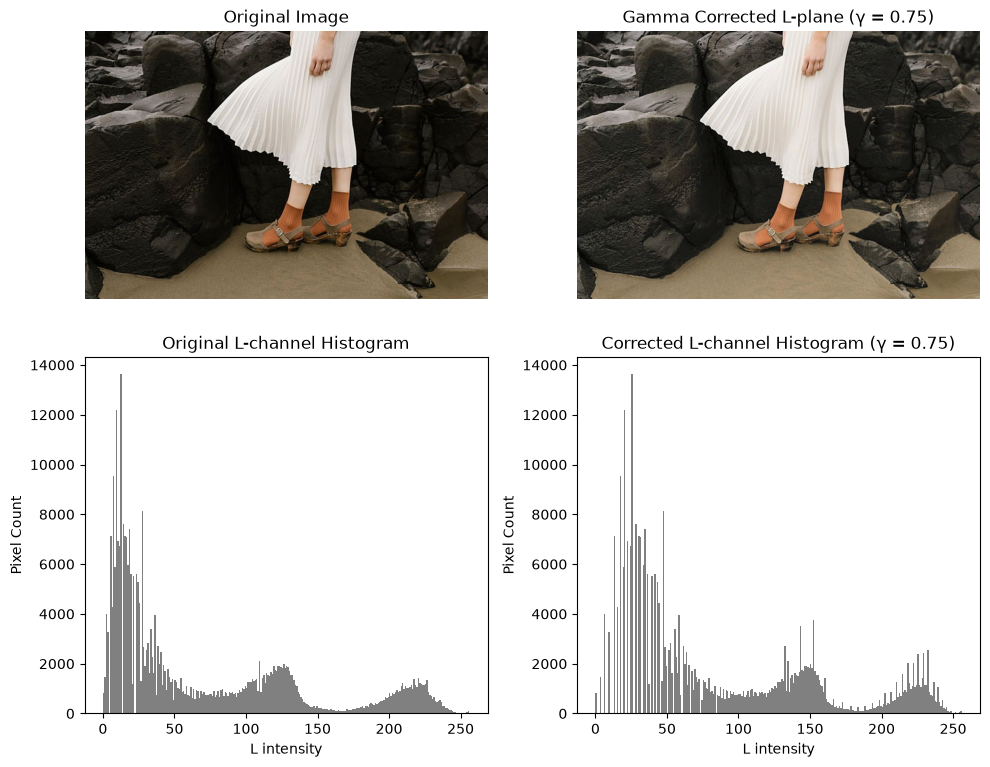

In [80]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Read Image
img_bgr = cv2.imread('C:\\Users\\USER\\EN3160-Assignment-01\\images\\question3.jpeg')  # Replace with your image file path
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# 2. Convert to LAB color space
img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
L, a, b = cv2.split(img_lab)

# 3. Apply Gamma Correction to L-plane
gamma = 0.75  # Adjust gamma: < 1.0 brightens, > 1.0 darkens
L_normalized = L / 255.0
L_corrected = np.uint8(np.clip(np.power(L_normalized, gamma) * 255, 0, 255))

# 4. Merge back and convert to RGB
lab_corrected = cv2.merge([L_corrected, a, b])
rgb_corrected = cv2.cvtColor(lab_corrected, cv2.COLOR_LAB2RGB)

# 5. Display Images and Histograms
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Images
axes[0, 0].imshow(img_rgb)
axes[0, 0].set_title("Original Image")
axes[0, 0].axis('off')

axes[0, 1].imshow(rgb_corrected)
axes[0, 1].set_title(f"Gamma Corrected L-plane (γ = {gamma})")
axes[0, 1].axis('off')

# Histograms of L-plane
axes[1, 0].hist(L.ravel(), bins=256, range=[0, 256], color='gray')
axes[1, 0].set_title("Original L-channel Histogram")
axes[1, 0].set_xlabel("L intensity")
axes[1, 0].set_ylabel("Pixel Count")

axes[1, 1].hist(L_corrected.ravel(), bins=256, range=[0, 256], color='gray')
axes[1, 1].set_title(f"Corrected L-channel Histogram (γ = {gamma})")
axes[1, 1].set_xlabel("L intensity")
axes[1, 1].set_ylabel("Pixel Count")

plt.tight_layout()
plt.show()

## Question 4


### (a)

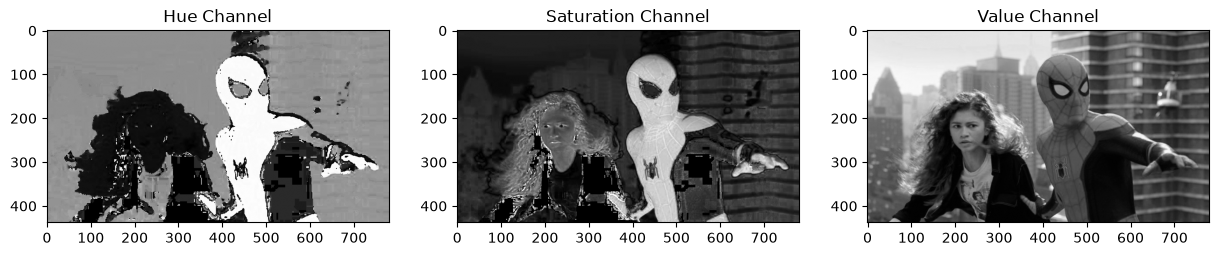

In [ ]:
image4=cv.imread('C:\\Users\\USER\\EN3160-Assignment-01\\images\\question4.jpeg')  # Read the image 
hsv=cv.cvtColor(image4,cv.COLOR_BGR2HSV)  # Convert to HSV color space
H,S,V=cv.split(hsv)  # Split into H, S, V channels

fig,axes=plt.subplots(1,3,figsize=(15,5))
axes[0].imshow(H,cmap='gray')
axes[0].set_title('Hue Channel')
axes[2].imshow(V,cmap='gray')
axes[2].set_title('Value Channel') 
axes[1].imshow(S,cmap='gray')
axes[1].set_title('Saturation Channel')    
plt.show()  # Show the plots

### (b)

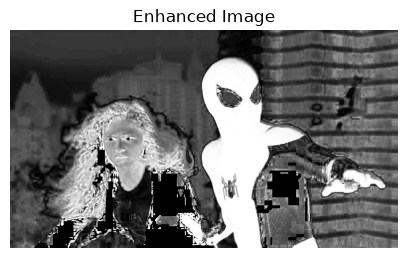

In [26]:
sigma=70
a=0.5
def transform_saturation(a):
    S_float = S.astype(np.float32)  # Convert to float for processing
    S_new = S_float + a*128*np.exp(-((S_float-128)**2)/(2*sigma**2))  # Apply Gaussian function
    S_new = np.minimum(S_new,255).astype(np.uint8)  # Ensure values are in [0, 255] and convert back to uint8
    hsv_new=cv.merge([H,S_new,V])  # Merge modified S channel back with H and V
    result=cv.cvtColor(hsv_new,cv.COLOR_HSV2BGR)  # Convert back to BGR color space
    result1=cv.cvtColor(result,cv.COLOR_BGR2RGB)
    return S_new

enhanced_image1 = transform_saturation(0.75)
plt.figure(figsize=(5,4))
plt.imshow(enhanced_image1,cmap='gray')
plt.title('Enhanced Image')
plt.axis('off')
plt.show()

### (c)

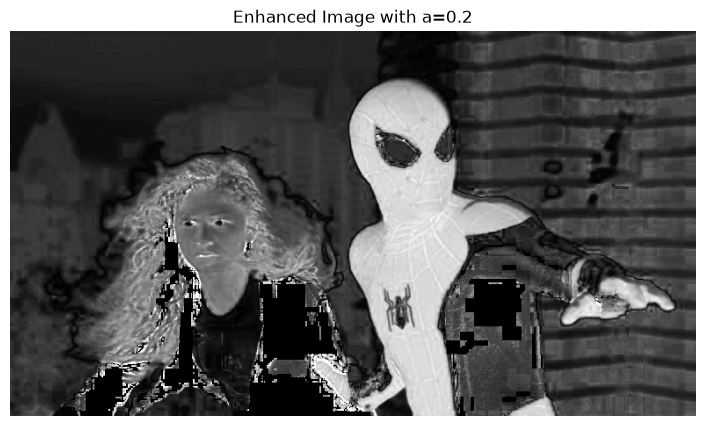

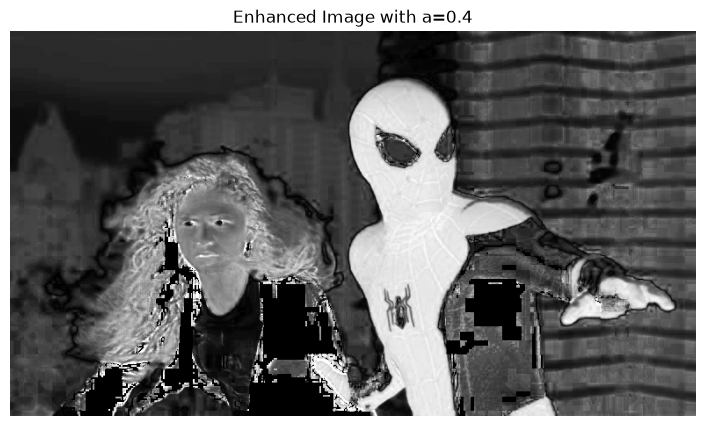

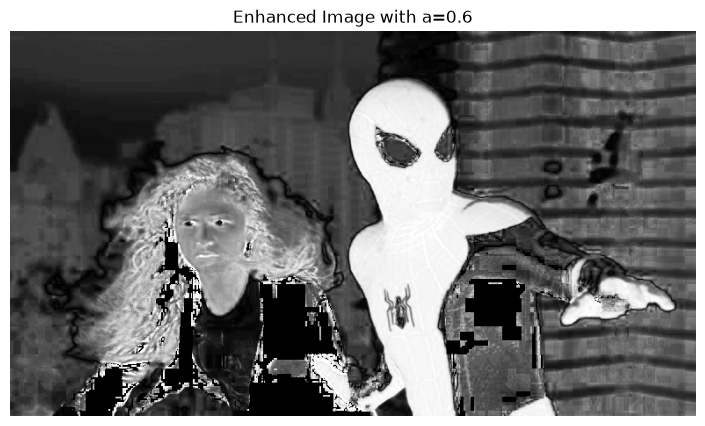

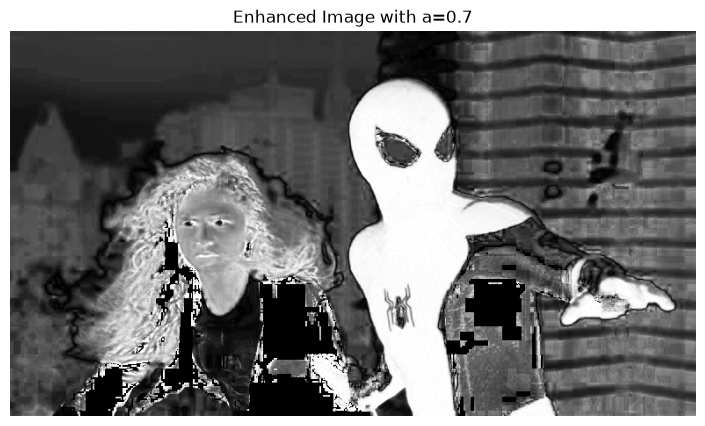

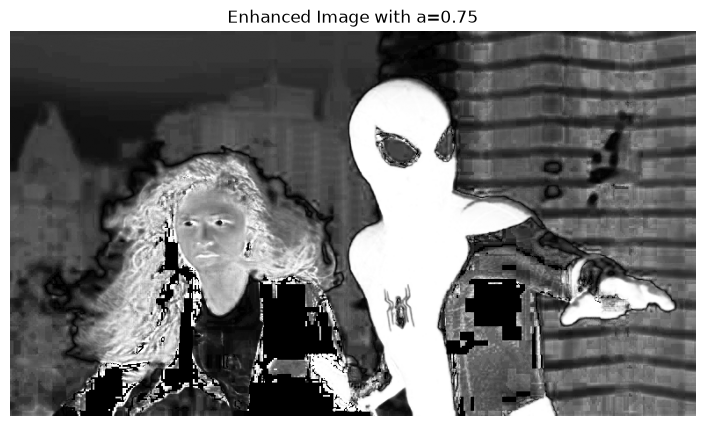

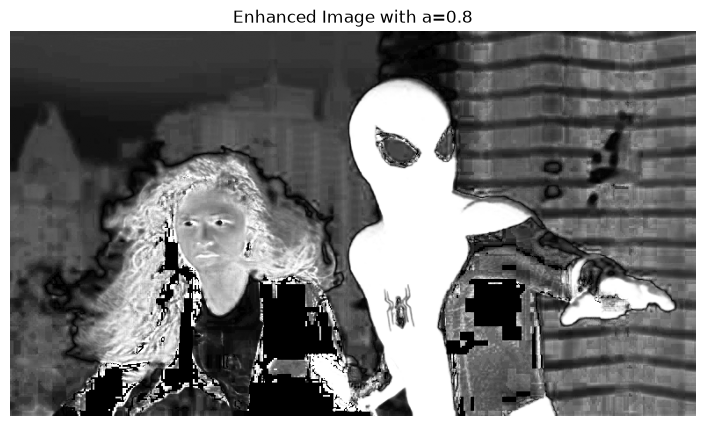

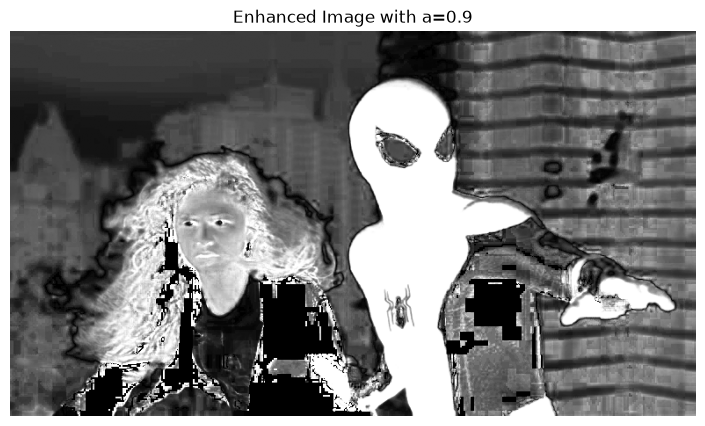

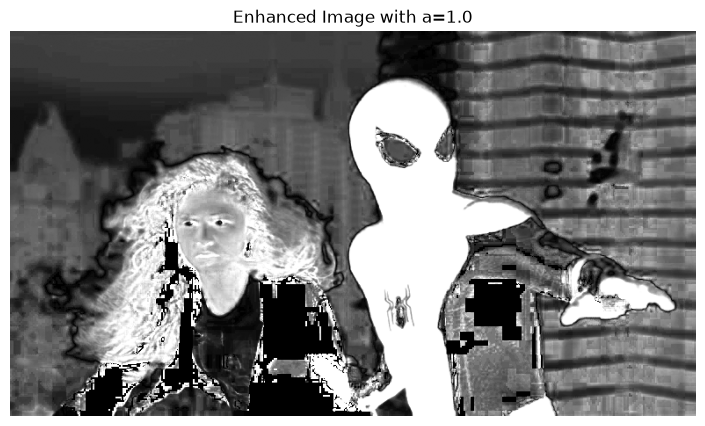

In [27]:
for a in [0.2,0.4,0.6,0.7,0.75,0.8,0.9,1.0]:
    resulting_image=transform_saturation(a)
    plt.figure(figsize=(10,5))
    plt.imshow(resulting_image,cmap='gray')
    plt.title(f'Enhanced Image with a={a}')
    plt.axis('off')
    plt.show()

### (d)


In [ ]:
#for the chosen value a=0.7, the image shows a significant enhancement in saturation, making the colors appear more vivid and vibrant. The Gaussian function applied to the saturation channel effectively boosts the mid-range saturation values while preventing oversaturation of already high saturation areas. This results in a more visually appealing image with improved color contrast and depth.
a=0.7
S_new = transform_saturation(a)  # Apply the transformation with a=0.75
hsv_new=cv.merge([H,S_new,V])  # Merge modified S channel back with H and V
result=cv.cvtColor(hsv_new,cv.COLOR_HSV2BGR)  # Convert back to BGR color space
enhanced_image=cv.cvtColor(result,cv.COLOR_BGR2RGB)

C:\Users\USER\AppData\Local\Temp\ipykernel_23116\2726827665.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


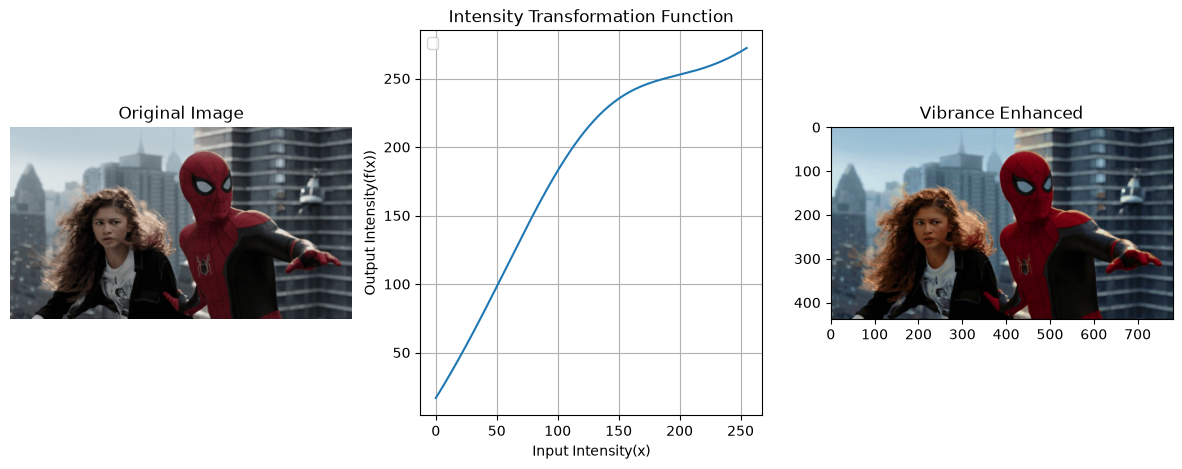

In [58]:
original_image=cv.cvtColor(image4,cv.COLOR_BGR2RGB)
x=np.arange(256,dtype=np.float32)
y = x + a*128*np.exp(-((x-128)**2)/(2*sigma**2))

fig,axes=plt.subplots(1,3,figsize=(15,5))
axes[0].imshow(original_image)
axes[0].set_title("Original Image")
axes[0].axis("off")
axes[2].imshow(enhanced_image)
axes[2].set_title('Vibrance Enhanced') 
axes[1].plot(x,y)
axes[1].set_title('Intensity Transformation Function')
axes[1].set_xlabel('Input Intensity(x)')
axes[1].set_ylabel('Output Intensity(f(x))')
axes[1].legend()
axes[1].grid()

## Queastion 5


Text(0, 0.5, 'Frequency')

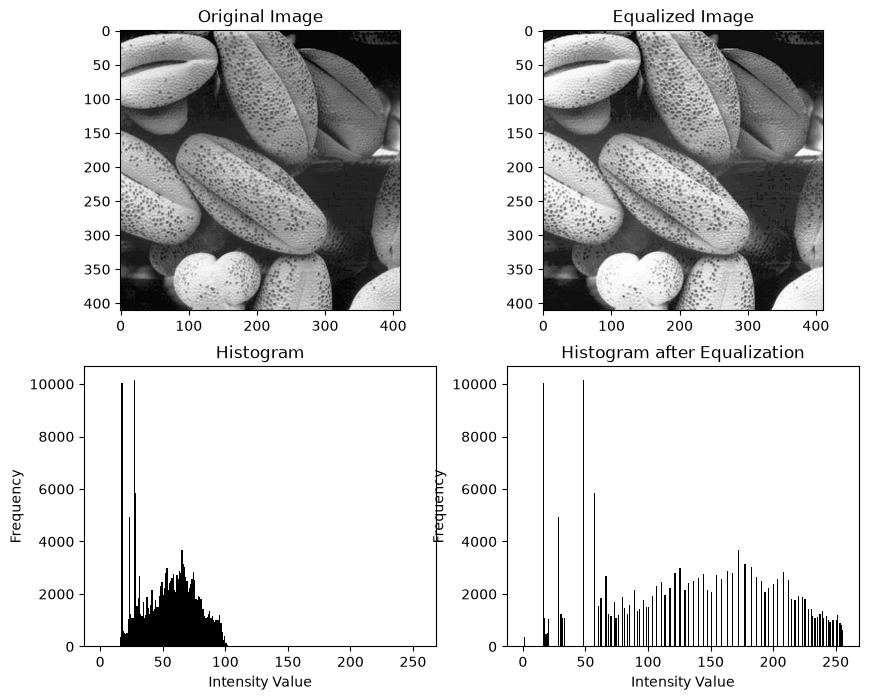

In [55]:
def histogram_equalization(image):
    histogram=np.zeros(256,dtype=np.int32) # Since there are intensity values from 0 to 255, we need an array of size 256
    for pixel in image.flatten():
        histogram[pixel] += 1  # Count the occurrences of each intensity value in the image

    # Now Calculate the cumulative distribution function (CDF) of the histogram
    cdf= np.cumsum(histogram)  

    #cdf_min= cdf[cdf > 0].min()  # Find the minimum non-zero value of the CDF
    num_pixels=image.size  # Total number of pixels in the image

    mapping = np.zeros(256, dtype=np.uint8)

    for i in range(256):
        mapping[i] = round((cdf[i] / num_pixels) * 255) 

    equalized_image=mapping[image]  # Map the original pixel values to the new equalized values using the CDF
    return equalized_image

image5=cv.imread('C:\\Users\\USER\\EN3160-Assignment-01\\images\\question5.png',cv.IMREAD_GRAYSCALE)  # Read the image
equalized_image = histogram_equalization(image5)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Images
axes[0, 0].imshow(image5, cmap='gray')
axes[0, 0].set_title('Original Image')

axes[0, 1].imshow(equalized_image, cmap='gray')
axes[0, 1].set_title('Equalized Image')

# Histograms
axes[1, 0].hist(image5.ravel(), bins=256, range=[0, 256], color='black')
axes[1, 0].set_title('Histogram')
axes[1, 0].set_xlabel('Intensity Value')
axes[1, 0].set_ylabel('Frequency')

axes[1, 1].hist(equalized_image.ravel(), bins=256, range=[0, 256], color='black')
axes[1, 1].set_title('Histogram after Equalization')
axes[1, 1].set_xlabel('Intensity Value')
axes[1, 1].set_ylabel('Frequency')




## Question 6

In [147]:
image6=cv.imread('C:\\Users\\USER\\EN3160-Assignment-01\\images\\question6.jpeg')  # Read the image in gray scale
hsv=cv.cvtColor(image6,cv.COLOR_BGR2HSV)  # Convert to HSV color space
H,S,V=cv.split(hsv)


Will choose the Saturation Channel


In [148]:
mask = cv.threshold(S,13,255,cv.THRESH_BINARY)[1]  # Create a binary mask 


In [149]:
foreground = cv.bitwise_and(image6, image6, mask=mask)  # Apply the mask to the original image

foreground_hsv = cv.cvtColor(foreground, cv.COLOR_BGR2HSV)  # Convert the foreground to HSV color space
fg_H,fg_S,fg_V=cv.split(foreground_hsv)  # Split the foreground into H, S, V channels   

# Now we take the pixels belonging to foreground'
foreground_pixels = fg_V[fg_V > 0]  # Get the pixel values of the foreground (non-zero pixels)

histogram = np.zeros(256, dtype=np.int32)  # Since there are intensity values from 0 to 255, we need an array of size 256
for pixel in foreground_pixels:
    histogram[pixel] += 1  # Count the occurrences of each intensity value in the foreground    



In [150]:
cdf = np.cumsum(histogram)  # Calculate the cumulative distribution function (CDF) of the histogram 

In [151]:
total_foreground_pixels = np.sum(histogram)  # Total number of foreground pixels    
mapping = np.zeros(256, dtype=np.uint8)

for i in range(256):
    mapping[i] = round((cdf[i] / total_foreground_pixels) * 255) 

equalized_V=mapping[fg_V]  # Map the original pixel values to the new equalized values using the CDF


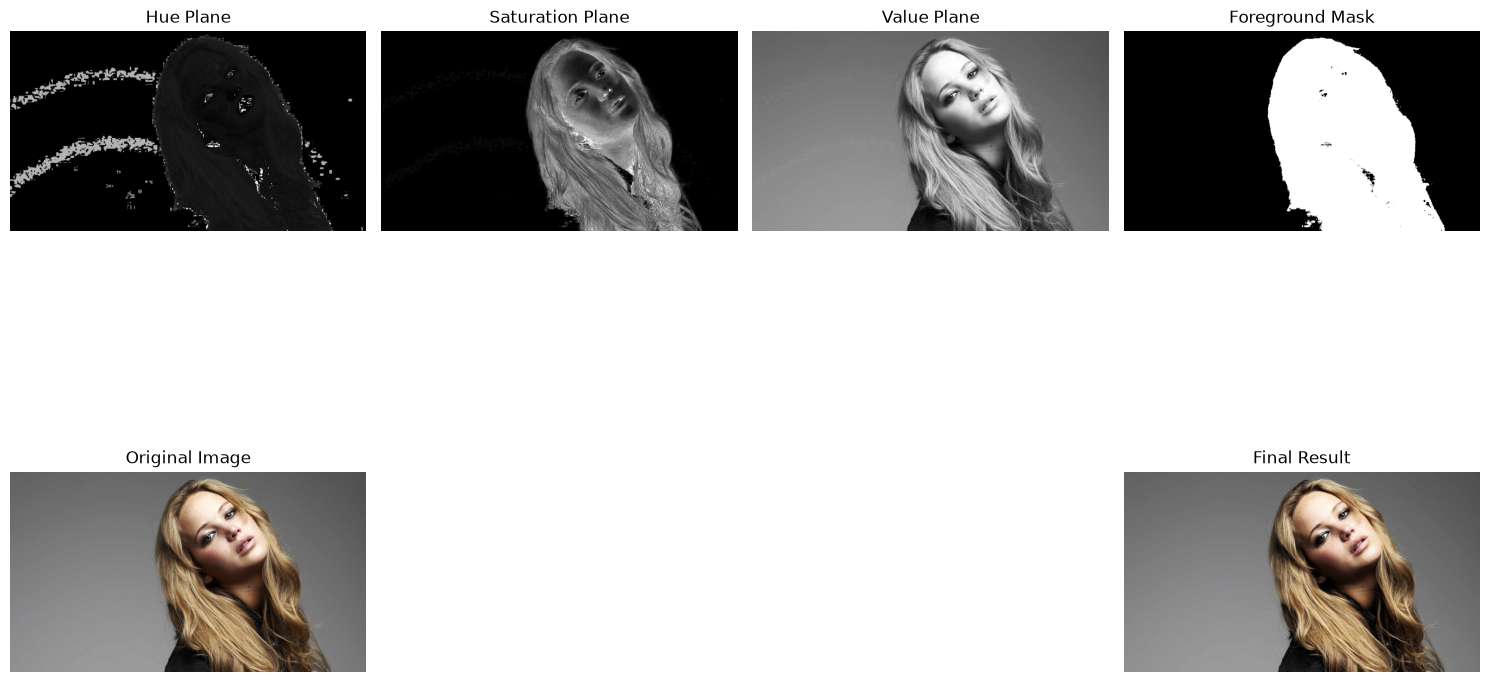

In [156]:
hsv_new = cv.merge([fg_H, fg_S, equalized_V])  # Combine the equalized foreground with the original background

equalized_foreground = cv.cvtColor(hsv_new, cv.COLOR_HSV2BGR)  # Convert back to BGR color space

# Extract the foreground for visualization
background = cv.bitwise_and(image6,image6, mask=cv.bitwise_not(mask))  # Get the background by inverting the mask

result_image = background + equalized_foreground  # Combine the background and equalized foreground

plt.figure(figsize=(15, 10))

plt.subplot(2, 4, 1)
plt.imshow(H, cmap='gray')
plt.title('Hue Plane')
plt.axis('off')

plt.subplot(2, 4, 2)
plt.imshow(S, cmap='gray')
plt.title('Saturation Plane')
plt.axis('off')

plt.subplot(2, 4, 3)
plt.imshow(V, cmap='gray')
plt.title('Value Plane')
plt.axis('off')

plt.subplot(2, 4, 4)
plt.imshow(mask, cmap='gray')
plt.title('Foreground Mask')
plt.axis('off')

plt.subplot(2, 4, 5)
plt.imshow(cv.cvtColor(image6, cv.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

#lt.subplot(2, 4, 6)
#plt.imshow(foreground, cmap='gray')
#plt.title('Foreground')
#plt.axis('off')

#plt.subplot(2, 4, 7)
#plt.imshow(equalized_foreground, cmap='gray')
#plt.title('Equalized Foreground')
#plt.axis('off')

plt.subplot(2, 4, 8)
plt.imshow(cv.cvtColor(result_image, cv.COLOR_BGR2RGB))
plt.title('Final Result')
plt.axis('off')

plt.tight_layout()
plt.show()



## Question 7


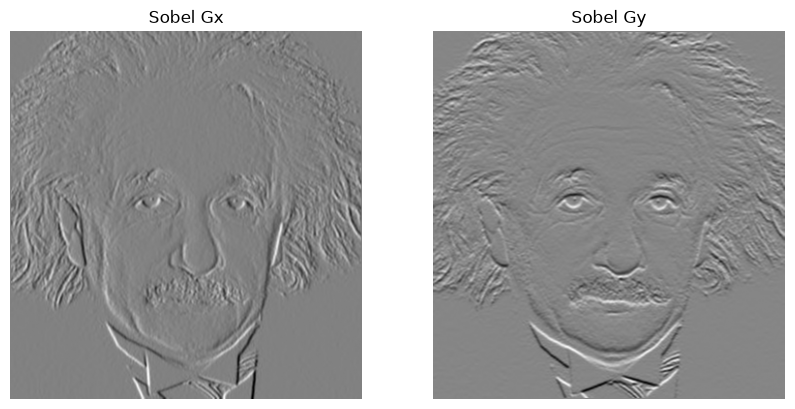

In [ ]:
image7 = cv.imread('C:\\Users\\USER\\EN3160-Assignment-01\\images\\question7.jpeg', cv.IMREAD_GRAYSCALE)

# Sobel in x direction
Gx_Kernel = np.array([[-1, 0, 1],
                  [-2, 0, 2],
                  [-1, 0, 1]])


# Sobel in y direction
Gy_Kernel = np.array([[-1, -2, -1],
                  [0, 0, 0],
                  [1, 2, 1]])

# Apply the kernels
Gx = cv.filter2D(image7, cv.CV_64F, Gx_Kernel)
Gy = cv.filter2D(image7, cv.CV_64F, Gy_Kernel)

# Gradient magnitude
G = np.sqrt(Gx**2 + Gy**2)

fig,axes=plt.subplots(1,2,figsize=(10, 8))

axes[0].imshow(Gx, cmap='gray')
axes[0].set_title('Sobel Gx')
axes[0].axis('off')

axes[1].imshow(Gy, cmap='gray')
axes[1].set_title('Sobel Gy')
axes[1].axis('off')

plt.show()

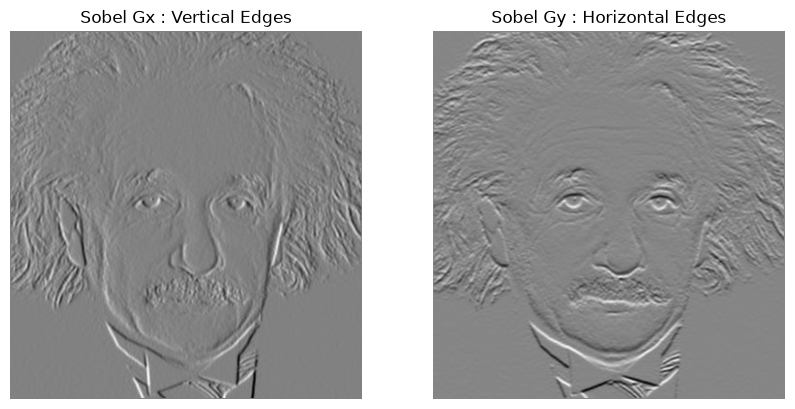

In [27]:
def sobel_filtering(image,kernel):
    rows, cols = image.shape
    filtered_image = np.zeros((rows, cols), dtype=np.float64) # This is what we are going to build yp

    for i in range(1, rows-1):
        for j in range(1, cols-1): # Here I ignored the border pixels to avoid boundary issues
            neighborhood_extracted = image[i-1:i+2, j-1:j+2]  # Extract the 3x3 neighborhood
            # Do the convolution operation: element-wise multiplication and sum
            calculated_value = np.sum(neighborhood_extracted * kernel)
            filtered_image[i, j] = calculated_value  # Assign the calculated value to the filtered

    return filtered_image

Gx=sobel_filtering(image7,Gx_Kernel)
Gy=sobel_filtering(image7,Gy_Kernel)
fig,axes=plt.subplots(1,2,figsize=(10, 8))
axes[0].imshow(Gx, cmap='gray') 
axes[0].set_title('Sobel Gx : Vertical Edges')
axes[1].imshow(Gy, cmap='gray')
axes[1].set_title('Sobel Gy : Horizontal Edges')
axes[0].axis('off')
axes[1].axis('off')
plt.show()


Using the seperabale property. This is mainly for efficiency


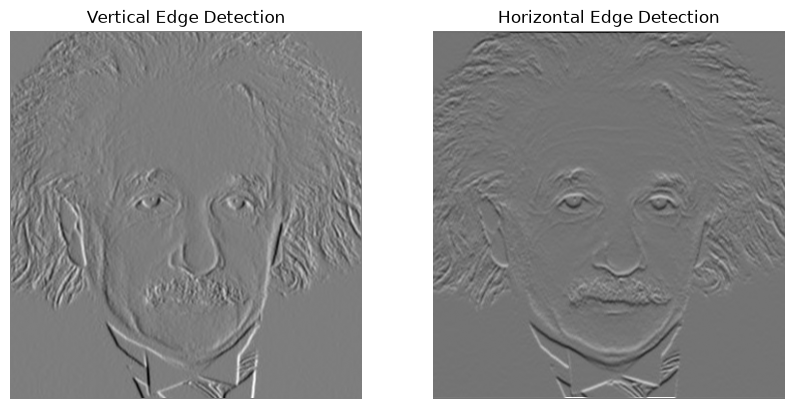

In [50]:
# First lets use Sobel filtering for vertical edge detection
horizontal_filter1 = np.array([1,0,-1]) 
vertical_smoothing1 =np.array([1,2,1]).reshape(3,1) # Here we reshape this as a column vector

image_after_vertical_filtering1= sobel_filtering(image7,vertical_smoothing1)

image_after_horizontal_filtering1 = sobel_filtering(image_after_vertical_filtering1,horizontal_filter1)
vertical_edges=image_after_horizontal_filtering1

# Then we perfom Horizontal edge detection
vertical_filter2 = np.array([1,0,-1]).reshape(3,1)   
horizontal_smoothing2 = np.array([1,2,1])

image_after_vertical_filtering2 = sobel_filtering(image7,horizontal_smoothing2)

image_after_horizontal_filtering2 = sobel_filtering(image_after_vertical_filtering1,vertical_filter2)
horizontal_edges=image_after_horizontal_filtering2

fig,axes=plt.subplots(1,2,figsize=(10, 8))
axes[0].imshow(vertical_edges, cmap='gray')
axes[0].set_title('Vertical Edge Detection')
axes[1].imshow(horizontal_edges, cmap='gray')
axes[1].set_title('Horizontal Edge Detection')
axes[0].axis('off')
axes[1].axis('off')
plt.show()



## Question 9


<>:1: SyntaxWarning: "\E" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\E"? A raw string is also an option.
<>:1: SyntaxWarning: "\E" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\E"? A raw string is also an option.
C:\Users\USER\AppData\Local\Temp\ipykernel_9548\116121793.py:1: SyntaxWarning: "\E" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\E"? A raw string is also an option.
  image9=cv.imread('C:\\Users\\USER\EN3160-Assignment-01\\images\\question9.jpeg')


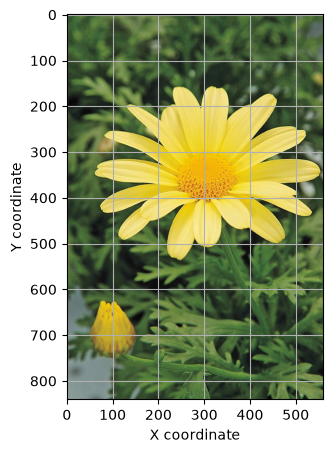

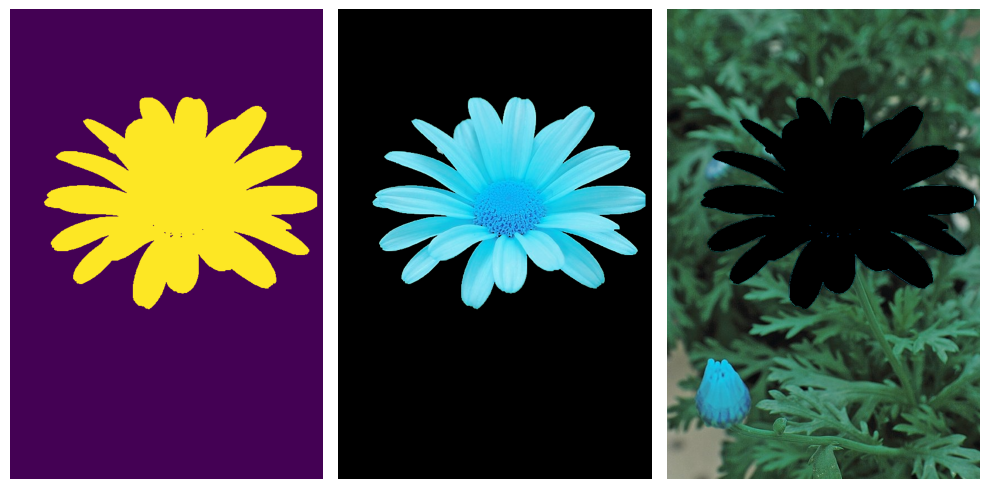

In [29]:
image9=cv.imread('C:\\Users\\USER\EN3160-Assignment-01\\images\\question9.jpeg')
mask=np.zeros(image9.shape[:2],np.uint8)

background_Model=np.zeros((1,65),np.float64)
foreground_model=np.zeros((1,65),np.float64)

# Now we built the rectangle, for that I manually choosing coordinates to get the rectangle
image_rgb = cv.cvtColor(image9, cv.COLOR_BGR2RGB)

# Display image with coordinates
plt.figure(figsize=(15, 5))
plt.imshow(image_rgb)
plt.xlabel("X coordinate")
plt.ylabel("Y coordinate")
plt.grid()
plt.show()

x = 50
y = 110

width = 550 - 50
height = 550 - 110

rect = (x, y, width, height)

cv.grabCut(
    image9,
    mask,
    rect,
    background_Model,
    foreground_model,
    5,
    cv.GC_INIT_WITH_RECT
)

final_mask = np.where(
    (mask == cv.GC_FGD) | (mask == cv.GC_PR_FGD),
    255,
    0
).astype(np.uint8)

#foreground image
foreground_image = cv.bitwise_and(
    image9,
    image9,
    mask=final_mask
)

# backgroun image
background_mask = cv.bitwise_not(final_mask)

background_image = cv.bitwise_and(
    image9,
    image9,
    mask=background_mask
)
fig,axes =plt.subplots(1,3,figsize=(10,8))
axes[0].imshow(final_mask)
axes[1].imshow(foreground_image)
axes[2].imshow(background_image)
axes[0].axis('off')
axes[1].axis('off')
axes[2].axis('off')
plt.tight_layout()
plt.show()

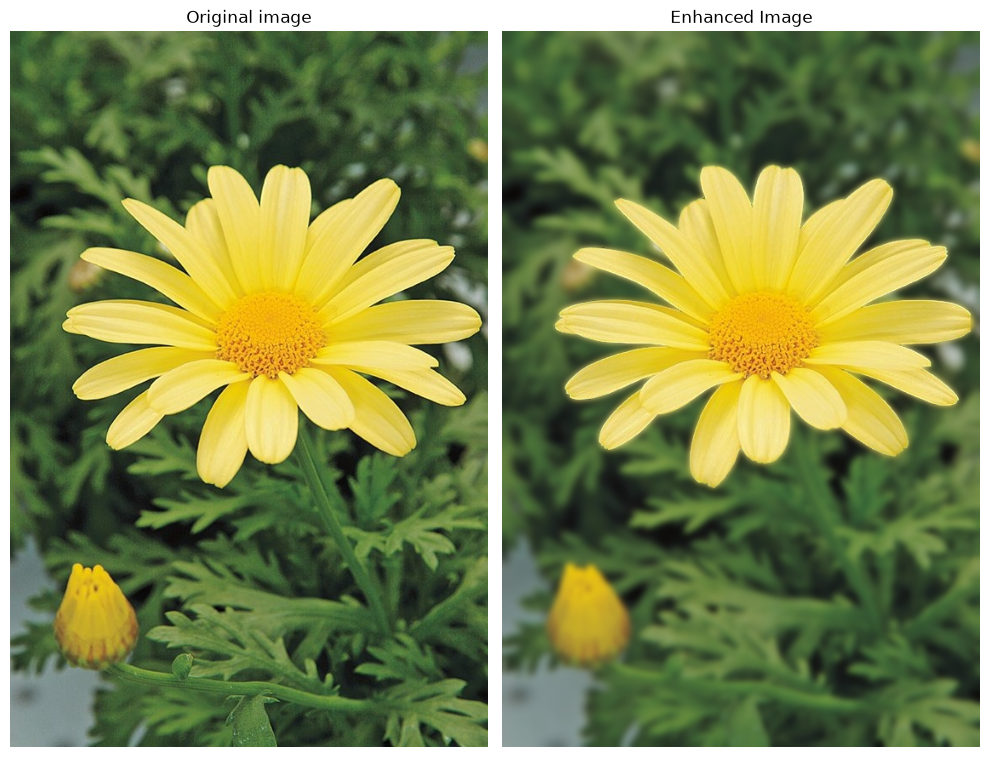

In [38]:
fully_blurred_image=cv.GaussianBlur(image9,(21,21),0)
blurred_background = cv.bitwise_and(fully_blurred_image,fully_blurred_image,mask=background_mask)

# Now I do the combining
enhanced_image=cv.add(foreground_image,blurred_background)

#original_image_rgb=cv.cvtColor(image9,cv.COLOR_BGR2RGB)
enhanced_image_rgb=cv.cvtColor(enhanced_image,cv.COLOR_BGR2RGB)

plt.figure(figsize=(10,8))
plt.subplot(1,2,1)
plt.imshow(image_rgb)
plt.title("Original image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(enhanced_image_rgb)
plt.title("Enhanced Image")
plt.axis('off')

plt.tight_layout()
plt.show()

The dark region near the edge of the flower can occur because the segmentation mask contains background(black) pixels close to the flower boundary. When Gaussian blurring is applied, these dark pixels are averaged with neighboring background pixels. This causes the dark pixels to spread slightly into the surrounding background, producing a dark halo around the flower.

## Question 10


in openCV sigmas(space) controls the spatial distance considered by the bilateral filter

i.e if that value is small, smoothing happens over a smaller area.

sigmar(color), controls how different two pixels can be in intensity and still be averaged together
i.e smaller values: pixels must have very similar intensity, has stronger edge preservation
larger values, more smoothing but potentially weaker edge preservation


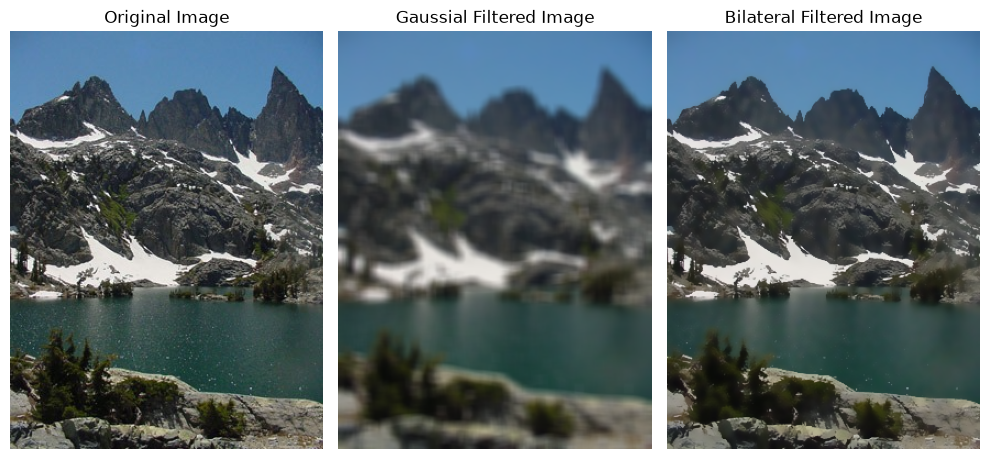

In [42]:
image10=cv.imread('C:\\Users\\USER\\EN3160-Assignment-01\\images\\question10.jpeg')
original_image=cv.cvtColor(image10, cv.COLOR_BGR2RGB)

gaussian_blurred=cv.GaussianBlur(image10,(9,9),75)
gb_image=cv.cvtColor(gaussian_blurred,cv.COLOR_BGR2RGB)

bilateral_im=cv.bilateralFilter(image10,d=9,sigmaColor=75,sigmaSpace=75)
bl_image=cv.cvtColor(bilateral_im,cv.COLOR_BGR2RGB)

plt.figure(figsize=(10,8))

plt.subplot(1,3,1)
plt.imshow(original_image)
plt.axis('off')
plt.title("Original Image")

plt.subplot(1,3,2)
plt.imshow(gb_image)
plt.axis('off')
plt.title("Gaussial Filtered Image")

plt.subplot(1,3,3)
plt.imshow(bl_image)
plt.axis('off')
plt.title("Bilateral Filtered Image")

plt.tight_layout()
plt.show()